<a href="https://colab.research.google.com/github/realRandomPL/ThucHanhDeepLearning/blob/main/ThucHanhDeepLearning_Tuan02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dữ liệu sau khi được làm sạch:
   Pclass  Sex   Age  familySize  Alone
0       3    0  22.0           2      0
1       1    1  38.0           2      0
2       3    1  26.0           1      1
3       1    1  35.0           2      0
4       3    0  35.0           1      1

--- 1. HUẤN LUYỆN VỚI TENSORFLOW ---
Epoch 1/30


/tmp/ipykernel_8202/47649925.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanicDisaster['Sex'] = titanicDisaster['Sex'].replace({'male': 0, 'female': 1})
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4424 - loss: 0.7763 - val_accuracy: 0.4581 - val_loss: 0.7477
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4691 - loss: 0.7358 - val_accuracy: 0.4804 - val_loss: 0.7063
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4944 - loss: 0.7022 - val_accuracy: 0.6089 - val_loss: 0.6712
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6053 - loss: 0.6736 - val_accuracy: 0.6536 - val_loss: 0.6425
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6475 - loss: 0.6499 - val_accuracy: 0.7263 - val_loss: 0.6155
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6840 - loss: 0.6276 - val_accuracy: 0.7430 - val_loss: 0.5950
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6924 - loss: 0.6099 - val_accuracy: 0.7821 - val_loss: 0.5760
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7051 - loss: 0.5938 - val_accuracy: 0.7821 - val_loss: 0.5607
Ep

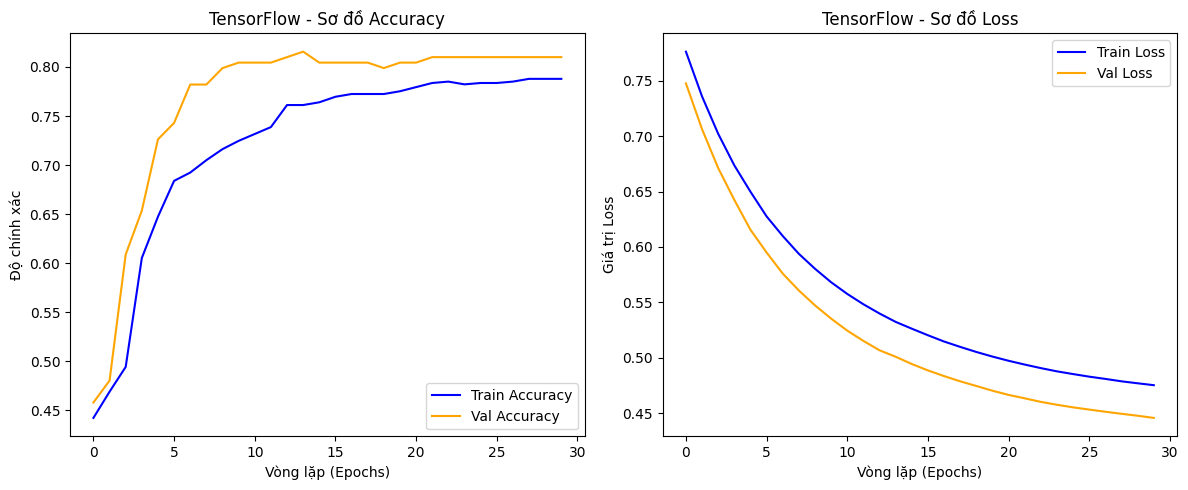


--- SƠ ĐỒ ĐÁNH GIÁ PYTORCH ---


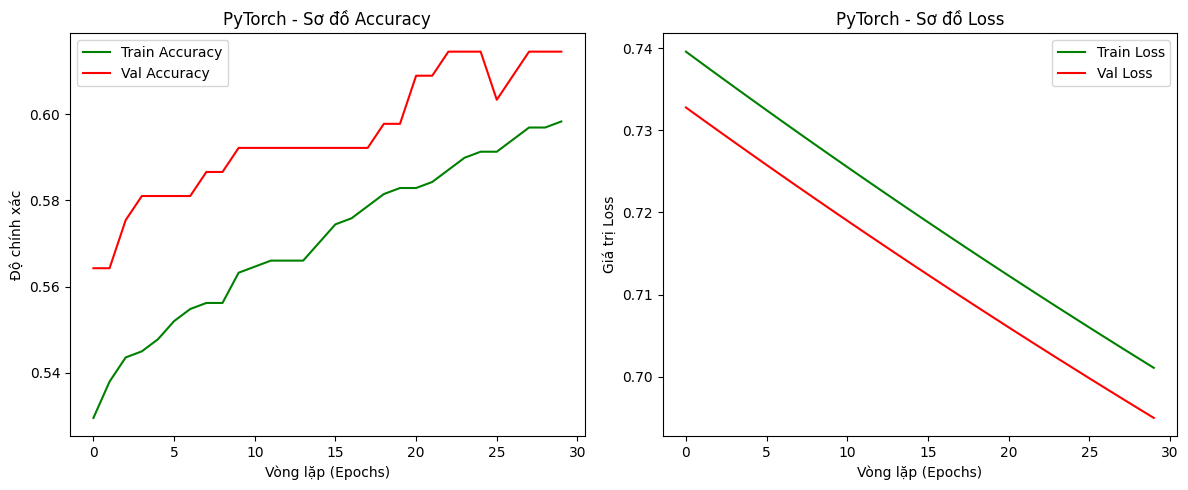

In [ ]:
###NGUYEN HOANG LOC####
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# BƯỚC 1: LÀM SẠCH DỮ LIỆU
# ==========================================
# Đọc dữ liệu
path = 'https://raw.githubusercontent.com/realRandomPL/ThucHanhDeepLearning/refs/heads/main/Data/titanic_disaster.csv'
titanicDisaster = pd.read_csv(path)

titanicDisaster['Sex'] = titanicDisaster['Sex'].replace({'male': 0, 'female': 1})
titanicDisaster['Sex'] = pd.to_numeric(titanicDisaster['Sex']) # Ép kiểu an toàn

# Xử lý thiếu dữ liệu Age bằng trung bình theo hạng vé (Pclass)
age_means = round(titanicDisaster.groupby('Pclass')['Age'].mean())
def fill_age(row):
    if pd.isnull(row['Age']):
        return age_means[row['Pclass']]
    return row['Age']

titanicDisaster['Age'] = titanicDisaster.apply(fill_age, axis=1)

# Xử lý Cabin bị thiếu bằng "Unknown" và tách loại Cabin (typeCabin)
titanicDisaster['Cabin'] = titanicDisaster['Cabin'].fillna('Unknown')
titanicDisaster['typeCabin'] = titanicDisaster['Cabin'].astype(str).str[0]

# Tạo đặc trưng familySize
titanicDisaster['familySize'] = 1 + titanicDisaster['SibSp'] + titanicDisaster['Parch']

# Tạo đặc trưng Alone
titanicDisaster['Alone'] = np.where(titanicDisaster['familySize'] == 1, 1, 0)

print("\nDữ liệu sau khi được làm sạch:")
print(titanicDisaster[['Pclass', 'Sex', 'Age', 'familySize', 'Alone']].head())


# ==========================================
# BƯỚC 2: THIẾT LẬP INPUT, TARGET VÀ CHUẨN HÓA (SCALER)
# ==========================================
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'familySize', 'Alone']
inputs = titanicDisaster[features].values
targets = titanicDisaster['Survived'].values

X_train, X_val, y_train, y_val = train_test_split(inputs, targets, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


# ==========================================
# BƯỚC 3: HUẤN LUYỆN (Sử dụng Gradient Descent)
# ==========================================

print("\n--- 1. HUẤN LUYỆN VỚI TENSORFLOW ---")
model_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train_scaled.shape[1],))
])

sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model_tf.compile(optimizer=sgd_optimizer,
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

history_tf = model_tf.fit(X_train_scaled, y_train,
                          epochs=30,
                          batch_size=32,
                          validation_data=(X_val_scaled, y_val),
                          verbose=1)


print("\n--- 2. HUẤN LUYỆN VỚI PYTORCH ---")
X_train_pt = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_pt = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_pt = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

class LinearProgressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearProgressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

model_pt = LinearProgressionModel(input_dim=X_train_scaled.shape[1])

criterion = nn.BCELoss()
optimizer = optim.SGD(model_pt.parameters(), lr=0.01)

epochs = 30
for epoch in range(epochs):
    model_pt.train()

    outputs = model_pt(X_train_pt)
    loss = criterion(outputs, y_train_pt)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        model_pt.eval()
        with torch.no_grad():
            val_outputs = model_pt(X_val_pt)
            val_loss = criterion(val_outputs, y_val_pt)
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')
# ==========================================
# BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH BẰNG SƠ ĐỒ (LOSS & ACCURACY)
# ==========================================
import matplotlib.pyplot as plt

print("\n--- SƠ ĐỒ ĐÁNH GIÁ TENSORFLOW ---")
# 4.1 Vẽ đồ thị cho TensorFlow (Sử dụng biến history_tf đã có)
plt.figure(figsize=(12, 5))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_tf.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_tf.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('TensorFlow - Sơ đồ Accuracy')
plt.xlabel('Vòng lặp (Epochs)')
plt.ylabel('Độ chính xác')
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history_tf.history['loss'], label='Train Loss', color='blue')
plt.plot(history_tf.history['val_loss'], label='Val Loss', color='orange')
plt.title('TensorFlow - Sơ đồ Loss')
plt.xlabel('Vòng lặp (Epochs)')
plt.ylabel('Giá trị Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------

print("\n--- SƠ ĐỒ ĐÁNH GIÁ PYTORCH ---")
# 4.2 Cập nhật vòng lặp PyTorch để lưu lịch sử và vẽ đồ thị
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Chạy lại vòng lặp PyTorch (30 epochs) có tích hợp bộ nhớ lưu trữ
epochs = 30
for epoch in range(epochs):
    model_pt.train()

    # Forward & Backward
    outputs = model_pt(X_train_pt)
    loss = criterion(outputs, y_train_pt)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Tính Accuracy trên tập Train
    train_preds = outputs.round()
    train_acc = (train_preds == y_train_pt).float().mean()

    # Đánh giá trên tập Val
    model_pt.eval()
    with torch.no_grad():
        val_outputs = model_pt(X_val_pt)
        val_loss = criterion(val_outputs, y_val_pt)
        val_preds = val_outputs.round()
        val_acc = (val_preds == y_val_pt).float().mean()

    # Lưu dữ liệu vào mảng để vẽ đồ thị
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

# Vẽ đồ thị cho PyTorch
plt.figure(figsize=(12, 5))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train Accuracy', color='green')
plt.plot(val_accs, label='Val Accuracy', color='red')
plt.title('PyTorch - Sơ đồ Accuracy')
plt.xlabel('Vòng lặp (Epochs)')
plt.ylabel('Độ chính xác')
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', color='green')
plt.plot(val_losses, label='Val Loss', color='red')
plt.title('PyTorch - Sơ đồ Loss')
plt.xlabel('Vòng lặp (Epochs)')
plt.ylabel('Giá trị Loss')
plt.legend()

plt.tight_layout()
plt.show()